<a href="https://colab.research.google.com/github/mfer1117/Proyecto-Neurohack-2026/blob/main/Final_entregar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# dataset ampliado a partir de los datos originales entregados por Bluba,
# datos generados de manera sintética -> 365 días de registro de eventos para cada paciente/consultante
df = pd.read_csv(
    "dataset_modelo_24h_365d.csv",
    sep=";"
)

df["fecha_indice"] = pd.to_datetime(df["fecha_indice"])

df = df.sort_values(
    ["id_caso", "fecha_indice"]
).reset_index(drop=True)

print(df.shape)
df.head()


(2920, 22)


,id_caso,fecha_indice,perfil_sensorial_predominante,rango_edad,calidad_sueno,modo_despertar,adherencia_medicacion,estado_gastrointestinal,nivel_regulacion_general_dia,asistencia_establecimiento,...,nivel_ruido_ambiente,transicion_dificil,hubo_sesion_profesional,nivel_alerta_inicial_sesion,nivel_alerta_final_sesion,eventos_mismo_dia,puntaje_riesgo_sintetico,crisis_proximas_24h,numero_crisis_proximas_24h,origen_fila
0,PAC-001,2026-02-26,Buscador Sensorial Vestibular y Propioceptivo,4-5 años,Reparador,Tranquilo/Alegre,No Aplica,Normal,Excelente,Asiste jornada completa,...,Bajo,No,Sí,Óptimo (Regulado),Óptimo (Regulado),0,0,1,1,Sintético longitudinal 365d
1,PAC-001,2026-02-27,Buscador Sensorial Vestibular y Propioceptivo,4-5 años,Reparador,Tranquilo/Alegre,No Aplica,Normal,Estable con Apoyo,Asiste jornada completa,...,Moderado,No,No,Sin sesión,Sin sesión,1,1,0,0,Sintético longitudinal 365d
2,PAC-001,2026-02-28,Buscador Sensorial Vestibular y Propioceptivo,4-5 años,Reparador,Tranquilo/Alegre,No Aplica,Normal,Estable con Apoyo,No aplica (fin de semana),...,Bajo,No,No,Sin sesión,Sin sesión,0,1,0,0,Sintético longitudinal 365d
3,PAC-001,2026-03-01,Buscador Sensorial Vestibular y Propioceptivo,4-5 años,Reparador,Tranquilo/Alegre,No Aplica,Normal,Estable con Apoyo,No aplica (fin de semana),...,Bajo,No,No,Sin sesión,Sin sesión,0,1,0,0,Sintético longitudinal 365d
4,PAC-001,2026-03-02,Buscador Sensorial Vestibular y Propioceptivo,4-5 años,Reparador,Tranquilo/Alegre,No Aplica,Normal,Estable con Apoyo,Asiste jornada completa,...,Bajo,No,No,Sin sesión,Sin sesión,0,1,0,0,Sintético longitudinal 365d


In [2]:
# Sueño
map_sueno = {
    "Reparador": 0.0,
    "Interrumpido": 0.6,
    "Dificultad de Conciliación": 1.0
}

df["carga_sueno"] = df["calidad_sueno"].map(map_sueno)

In [3]:
# Despertar
map_despertar = {
    "Tranquilo/Alegre": 0.0,
    "Cansado/Con Sueño": 0.5,
    "Irritable/Llorando": 1.0
}

df["carga_despertar"] = df["modo_despertar"].map(map_despertar)

In [4]:
# Estado gastrointestinal
map_gi = {
    "Normal": 0.0,
    "Estreñimiento": 0.6,
    "Diarrea": 1.0
}

df["carga_gi"] = df["estado_gastrointestinal"].map(map_gi)

In [5]:
# Regulación diaria
map_regulacion = {
    "Excelente": 0.0,
    "Estable con Apoyo": 0.4,
    "Desregulación Frecuente": 1.0
}

df["carga_regulacion"] = (
    df["nivel_regulacion_general_dia"]
    .map(map_regulacion)
)

In [7]:
df["carga_cambio_rutina"] = (
    df["cambio_rutina_escolar"] == "Sí"
).astype(float)

df["carga_transicion"] = (
    df["transicion_dificil"] == "Sí"
).astype(float)

In [8]:
map_demanda = {
    "Baja": 0.0,
    "Moderada": 0.4,
    "Alta": 1.0
}

df["carga_demanda"] = (
    df["carga_demanda_academica"]
    .map(map_demanda)
)

In [9]:
map_ruido = {
    "Bajo": 0.0,
    "Moderado": 0.4,
    "Alto": 1.0
}

df["carga_ruido"] = (
    df["nivel_ruido_ambiente"]
    .map(map_ruido)
)

In [10]:
map_alerta = {
    "Sin sesión": 0.0,
    "Óptimo (Regulado)": 0.0,
    "Bajo (Letárgico)": 0.5,
    "Alto (Sobreexcitado)": 1.0
}

df["carga_alerta"] = (
    df["nivel_alerta_inicial_sesion"]
    .map(map_alerta)
)

In [15]:
# estas ponderaciones a futuro se irán ajustando mediante machine learning
# son individuales para cada paciente según su historial y características
# ponderaciones de ejemplo para comenzar, según tendencias comunes
# el objetivo es hacer un modelo donde se tome en cuenta la acumulación diferenciada de los distintos factores

pesos = {
    "carga_sueno": 1.3,
    "carga_despertar": 1.2,
    "carga_gi": 0.8,
    "carga_regulacion": 1.8,
    "carga_cambio_rutina": 1.0,
    "carga_transicion": 1.4,
    "carga_demanda": 0.8,
    "carga_ruido": 1.0,
    "carga_alerta": 1.4
}

In [16]:
df["carga_diaria"] = 0

for variable, peso in pesos.items():
    df["carga_diaria"] += df[variable] * peso

In [17]:
peso_maximo = sum(pesos.values())

df["carga_diaria_pct"] = (
    df["carga_diaria"] /
    peso_maximo *
    100
)

In [18]:
df[
    [
        "id_caso",
        "fecha_indice",
        "carga_diaria_pct",
        "crisis_proximas_24h" # esta variable se incorporó en el dataset ampliado teniendo en cuenta los registros históricos
    ]
].head(20)

,id_caso,fecha_indice,carga_diaria_pct,crisis_proximas_24h
0,PAC-001,2026-02-26,2.990654,1
1,PAC-001,2026-02-27,13.457944,0
2,PAC-001,2026-02-28,6.728972,0
3,PAC-001,2026-03-01,6.728972,0
4,PAC-001,2026-03-02,6.728972,0
5,PAC-001,2026-03-03,6.728972,0
6,PAC-001,2026-03-04,6.728972,0
7,PAC-001,2026-03-05,0.000000,0
8,PAC-001,2026-03-06,20.560748,0
9,PAC-001,2026-03-07,22.429907,0


In [19]:
def carga_acumulada(grupo):
    actual = grupo
    ayer = grupo.shift(1)
    anteayer = grupo.shift(2)

    return (
        actual * 1.0 +
        ayer.fillna(0) * 0.7 +
        anteayer.fillna(0) * 0.4
    )

df["ICAD"] = (
    df.groupby("id_caso")["carga_diaria_pct"]
      .transform(carga_acumulada)
)

In [20]:
df["ICAD_pct"] = (
    df["ICAD"] / 210 * 100
)

In [22]:
# diferencia de "acumulada" entre dos días consecutivos
df["delta_carga_1d"] = (
    df.groupby("id_caso")["carga_diaria_pct"]
      .diff()
)

In [23]:
df["tendencia_carga_3d"] = (
    df.groupby("id_caso")["carga_diaria_pct"]
      .transform(
          lambda x: x.rolling(3, min_periods=2)
                     .apply(
                         lambda y: y.iloc[-1] - y.iloc[0],
                         raw=False
                     )
      )
)

In [24]:
df.groupby(
    "crisis_proximas_24h"
)[
    ["carga_diaria_pct", "ICAD_pct", "delta_carga_1d"]
].mean()

,carga_diaria_pct,ICAD_pct,delta_carga_1d
crisis_proximas_24h,,,
0,11.365794,11.367954,-0.047875
1,15.214383,14.823021,0.633079


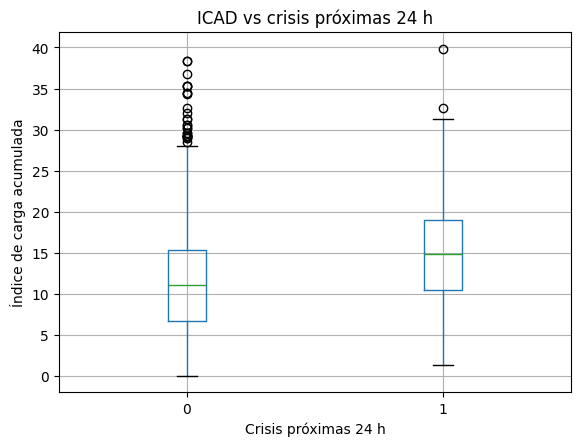

In [25]:
import matplotlib.pyplot as plt

df.boxplot(
    column="ICAD_pct",
    by="crisis_proximas_24h"
)

plt.title("ICAD vs crisis próximas 24 h")
plt.suptitle("")
plt.xlabel("Crisis próximas 24 h")
plt.ylabel("Índice de carga acumulada")
plt.show()

In [26]:
from sklearn.metrics import roc_auc_score

auc_icad = roc_auc_score(
    df["crisis_proximas_24h"],
    df["ICAD_pct"]
)

print("ROC-AUC ICAD:", auc_icad)

ROC-AUC ICAD: 0.6545801526717557


In [27]:
features_extra = [
    "carga_diaria_pct",
    "ICAD_pct",
    "delta_carga_1d",
    "tendencia_carga_3d"
]

In [28]:
df["delta_carga_1d"] = df["delta_carga_1d"].fillna(0)
df["tendencia_carga_3d"] = df["tendencia_carga_3d"].fillna(0)

In [29]:
columnas_eliminar = [
    "crisis_proximas_24h",
    "numero_crisis_proximas_24h",
    "puntaje_riesgo_sintetico",
    "id_caso",
    "fecha_indice",
    "origen_fila"
]

X = df.drop(
    columns=columnas_eliminar,
    errors="ignore"
)

y = df["crisis_proximas_24h"]

In [30]:
fechas = sorted(df["fecha_indice"].unique())

punto_corte = int(len(fechas) * 0.75)
fecha_corte = fechas[punto_corte]

train_mask = df["fecha_indice"] < fecha_corte
test_mask = df["fecha_indice"] >= fecha_corte

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

In [31]:
columnas_numericas = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

columnas_categoricas = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numéricas:")
print(columnas_numericas)

print("\nCategóricas:")
print(columnas_categoricas)

Numéricas:
['eventos_mismo_dia', 'carga_sueno', 'carga_despertar', 'carga_gi', 'carga_regulacion', 'carga_cambio_rutina', 'carga_transicion', 'carga_demanda', 'carga_ruido', 'carga_alerta', 'carga_diaria', 'carga_diaria_pct', 'ICAD', 'ICAD_pct', 'delta_carga_1d', 'tendencia_carga_3d']

Categóricas:
['perfil_sensorial_predominante', 'rango_edad', 'calidad_sueno', 'modo_despertar', 'adherencia_medicacion', 'estado_gastrointestinal', 'nivel_regulacion_general_dia', 'asistencia_establecimiento', 'cambio_rutina_escolar', 'carga_demanda_academica', 'nivel_ruido_ambiente', 'transicion_dificil', 'hubo_sesion_profesional', 'nivel_alerta_inicial_sesion', 'nivel_alerta_final_sesion']


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

pipeline_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", pipeline_numerico, columnas_numericas),
    ("cat", pipeline_categorico, columnas_categoricas)
])

modelo_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42
)

modelo_icad = Pipeline([
    ("preprocesamiento", preprocesador),
    ("clasificador", modelo_rf)
])

modelo_icad.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['eventos_mismo_dia',
                                                   'carga_sueno',
                                                   'carga_despertar',
                                                   'carga_gi',
                                                   'carga_regulacion',
                                                   'carga_cambio_rutina',
                                                   'carga_transicion',
                                                   'carga_demanda',
                                                   'carga_ruido',
                                                   'carga_alerta',
                                                   'carga_diaria',
                                                   'carga_diaria_pct', 'ICAD',
                                                   'I...
                                                   'asistencia_establecimiento',
                                                   'cambio_rutina_escolar',
                                                   'carga_demanda_academica',
                                                   'nivel_ruido_ambiente',
                                                   'transicion_dificil',
                                                   'hubo_sesion_profesional',
                                                   'nivel_alerta_inicial_sesion',
                                                   'nivel_alerta_final_sesion'])])),
                ('clasificador',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=7, min_samples_leaf=2,
                                        n_estimators=500, random_state=42))])

In [34]:
from sklearn.metrics import average_precision_score

y_prob_icad = modelo_icad.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_icad)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, y_prob_icad)
)

ROC-AUC: 0.8877575730891158
PR-AUC: 0.5706790949533042


In [37]:
# Matriz de confusión RF - umbral 0,5
y_pred_rf = (y_prob_icad >= 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=3))

[[611  57]
 [ 20  48]]
              precision    recall  f1-score   support

           0      0.968     0.915     0.941       668
           1      0.457     0.706     0.555        68

    accuracy                          0.895       736
   macro avg      0.713     0.810     0.748       736
weighted avg      0.921     0.895     0.905       736



In [38]:
# Prevalencia en train y test
print("Train")
print(y_train.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Train
crisis_proximas_24h
0    0.911172
1    0.088828
Name: proportion, dtype: float64

Test
crisis_proximas_24h
0    0.907609
1    0.092391
Name: proportion, dtype: float64


In [39]:
# Ver importancia de variables
rf = modelo_icad.named_steps["clasificador"]

feature_names = modelo_icad.named_steps["preprocesamiento"].get_feature_names_out()

imp = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# print(imp.head(20))

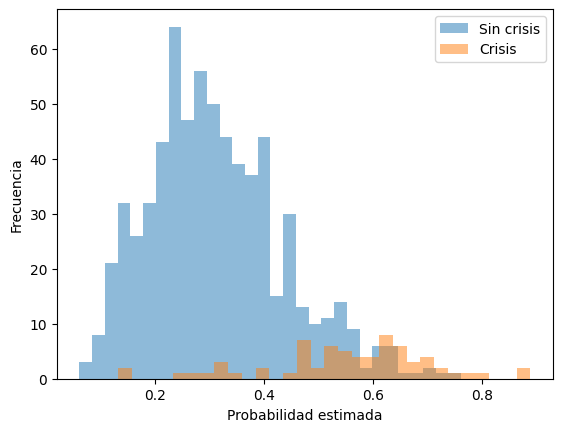

In [40]:
import matplotlib.pyplot as plt

plt.hist(y_prob_icad[y_test == 0], bins=30, alpha=0.5, label="Sin crisis")
plt.hist(y_prob_icad[y_test == 1], bins=30, alpha=0.5, label="Crisis")

plt.xlabel("Probabilidad estimada")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [42]:
# prueba métricas del modelo a distintos umbrales
# definición binaria: sí crisis, no crisis
from sklearn.metrics import confusion_matrix

umbrales = np.arange(0.3, 0.81, 0.05)

for u in umbrales:
    pred = (y_prob_icad >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    sensibilidad = tp / (tp + fn)
    especificidad = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(
        round(u, 2),
        "sens:", round(sensibilidad, 3),
        "esp:", round(especificidad, 3),
        "prec:", round(precision, 3),
        "FP:", fp,
        "FN:", fn
    )

0.3 sens: 0.941 esp: 0.504 prec: 0.162 FP: 331 FN: 4
0.35 sens: 0.882 esp: 0.657 prec: 0.208 FP: 229 FN: 8
0.4 sens: 0.853 esp: 0.787 prec: 0.29 FP: 142 FN: 10
0.45 sens: 0.824 esp: 0.868 prec: 0.389 FP: 88 FN: 12
0.5 sens: 0.706 esp: 0.915 prec: 0.457 FP: 57 FN: 20
0.55 sens: 0.544 esp: 0.957 prec: 0.561 FP: 29 FN: 31
0.6 sens: 0.426 esp: 0.973 prec: 0.617 FP: 18 FN: 39
0.65 sens: 0.206 esp: 0.993 prec: 0.737 FP: 5 FN: 54
0.7 sens: 0.147 esp: 0.996 prec: 0.769 FP: 3 FN: 58
0.75 sens: 0.059 esp: 0.999 prec: 0.8 FP: 1 FN: 64
0.8 sens: 0.044 esp: 1.0 prec: 1.0 FP: 0 FN: 65


In [43]:
# visualizar como tabla
resultados = []

for u in np.arange(0.40, 0.71, 0.05):
    pred = (y_prob_icad >= u).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred
    ).ravel()

    resultados.append({
        "umbral": round(u, 2),
        "sensibilidad": tp / (tp + fn),
        "especificidad": tn / (tn + fp),
        "precision": tp / (tp + fp) if (tp + fp) else 0,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

pd.DataFrame(resultados)

,umbral,sensibilidad,especificidad,precision,FP,FN,TP,TN
0,0.40,0.852941,0.787425,0.290000,142,10,58,526
1,0.45,0.823529,0.868263,0.388889,88,12,56,580
2,0.50,0.705882,0.914671,0.457143,57,20,48,611
3,0.55,0.544118,0.956587,0.560606,29,31,37,639
4,0.60,0.426471,0.973054,0.617021,18,39,29,650
5,0.65,0.205882,0.992515,0.736842,5,54,14,663
6,0.70,0.147059,0.995509,0.769231,3,58,10,665


In [44]:
y_prob_icad = modelo_icad.predict_proba(X_test)[:, 1]

In [45]:
# entregar resultado por nivel relativo de riesgo de crisis
def clasificar_riesgo(p):
    if p < 0.45:
        return "Bajo"
    elif p < 0.60:
        return "Moderado"
    else:
        return "Alto"

In [47]:
niveles_riesgo = [
    clasificar_riesgo(p)
    for p in y_prob_icad
]
resultados_riesgo = X_test.copy()

resultados_riesgo["riesgo_24h"] = y_prob_icad
resultados_riesgo["riesgo_pct"] = y_prob_icad * 100
resultados_riesgo["nivel_riesgo"] = niveles_riesgo
resultados_riesgo["crisis_real"] = y_test.values

resultados_riesgo[
    ["riesgo_pct", "nivel_riesgo", "crisis_real"]
].head(20)

,riesgo_pct,nivel_riesgo,crisis_real
273,22.733533,Bajo,0
274,25.370104,Bajo,0
275,22.679206,Bajo,0
276,32.004775,Bajo,0
277,23.521765,Bajo,0
278,54.060491,Moderado,0
279,40.140612,Bajo,0
280,25.319242,Bajo,0
281,37.234558,Bajo,0
282,24.866687,Bajo,0


/tmp/ipykernel_828/4236399914.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = resultados_riesgo.groupby(['nivel_riesgo', 'crisis_real']).size().unstack(fill_value=0)


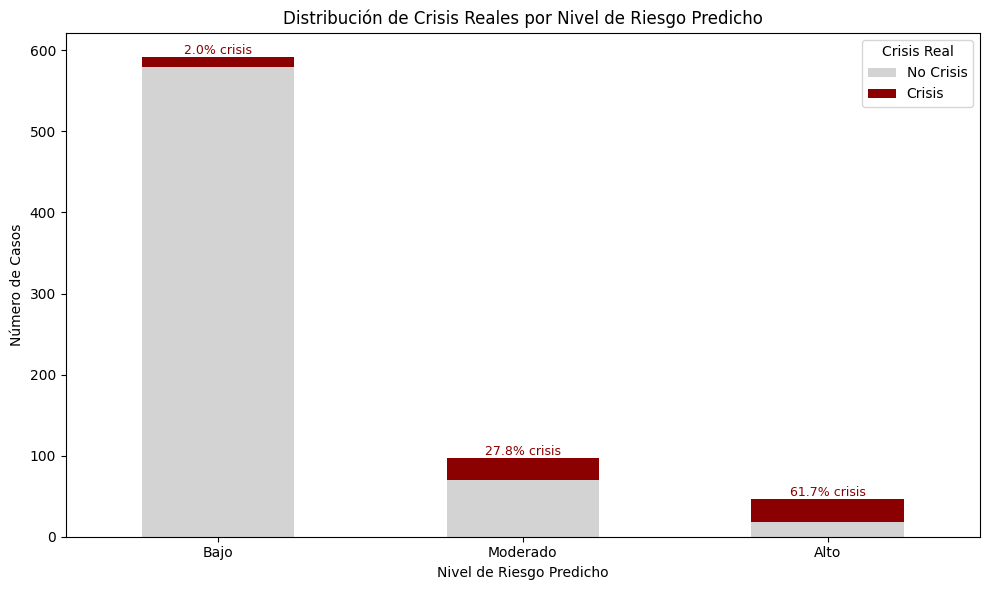

In [48]:
# gráfico para visulaizar la cantidad de casos que realmente terminaron en crisis (Crisis Real = 1)
# y los que no (Crisis Real = 0) para cada uno de los niveles de riesgo predichos (Bajo, Moderado, Alto)
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar que las categorías de 'nivel_riesgo' estén ordenadas
orden_niveles = ["Bajo", "Moderado", "Alto"]
resultados_riesgo["nivel_riesgo"] = pd.Categorical(
    resultados_riesgo["nivel_riesgo"],
    categories=orden_niveles,
    ordered=True
)

# Calcular conteos para apilar las barras
counts = resultados_riesgo.groupby(['nivel_riesgo', 'crisis_real']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))

# Trazar las barras apiladas
counts.plot(kind='bar', stacked=True, color={0: "lightgray", 1: "darkred"}, ax=ax)

ax.set_title("Distribución de Crisis Reales por Nivel de Riesgo Predicho")
ax.set_xlabel("Nivel de Riesgo Predicho")
ax.set_ylabel("Número de Casos")
ax.set_xticklabels(orden_niveles, rotation=0) # Asegurar que las etiquetas del eje x no roten
ax.legend(title="Crisis Real", labels=["No Crisis", "Crisis"])

# Añadir porcentajes en la parte superior de las barras de 'Crisis'
for i, nivel in enumerate(orden_niveles):
    total_cases = counts.loc[nivel].sum()
    if total_cases > 0:
        crisis_count = counts.loc[nivel, 1]
        crisis_percentage = (crisis_count / total_cases) * 100
        # Posicionar el texto encima de la parte 'Crisis' de la barra
        ax.text(
            i, # Coordenada x (posición de la barra)
            counts.loc[nivel, 0] + counts.loc[nivel, 1], # Coordenada y (parte superior de la pila)
            f'{crisis_percentage:.1f}% crisis', # Texto del porcentaje
            ha='center',
            va='bottom',
            color='darkred',
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [50]:
# función para probar la incorporación de nuevos datos del paciente/consultor
def estimar_riesgo_bluba(modelo, X_nuevo):
    p = modelo.predict_proba(X_nuevo)[:, 1][0]
    nivel = clasificar_riesgo(p)

    if nivel == "Bajo":
        mensaje = "Las observaciones recientes se asocian con un riesgo bajo de desregulación en las próximas 24 horas."
    elif nivel == "Moderado":
        mensaje = "Las observaciones recientes sugieren un riesgo moderado de desregulación. Se recomienda mayor atención y seguimiento."
    else:
        mensaje = "Las observaciones recientes se asocian con un riesgo alto de desregulación en las próximas 24 horas."

    return {
        "score": float(p),
        "riesgo_pct": round(p * 100, 1),
        "nivel": nivel,
        "mensaje": mensaje
    }

In [52]:
X_train.columns.tolist()

['perfil_sensorial_predominante',
 'rango_edad',
 'calidad_sueno',
 'modo_despertar',
 'adherencia_medicacion',
 'estado_gastrointestinal',
 'nivel_regulacion_general_dia',
 'asistencia_establecimiento',
 'cambio_rutina_escolar',
 'carga_demanda_academica',
 'nivel_ruido_ambiente',
 'transicion_dificil',
 'hubo_sesion_profesional',
 'nivel_alerta_inicial_sesion',
 'nivel_alerta_final_sesion',
 'eventos_mismo_dia',
 'carga_sueno',
 'carga_despertar',
 'carga_gi',
 'carga_regulacion',
 'carga_cambio_rutina',
 'carga_transicion',
 'carga_demanda',
 'carga_ruido',
 'carga_alerta',
 'carga_diaria',
 'carga_diaria_pct',
 'ICAD',
 'ICAD_pct',
 'delta_carga_1d',
 'tendencia_carga_3d']

In [53]:
# simulación de registro de nuevos datos del paciente/consultor
X_nuevo = pd.DataFrame([{
    "perfil_sensorial_predominante": "Hipersensible Auditivo y Evitador Táctil",
    "rango_edad": "6-7 años",
    "calidad_sueno": "Interrumpido",
    "modo_despertar": "Cansado/Con Sueño",
    "adherencia_medicacion": "No Aplica",
    "estado_gastrointestinal": "Normal",
    "nivel_regulacion_general_dia": "Estable con Apoyo",
    "asistencia_establecimiento": "Asiste jornada completa",
    "cambio_rutina_escolar": "Sí",
    "carga_demanda_academica": "Alta",
    "nivel_ruido_ambiente": "Alto",
    "transicion_dificil": "Sí",
    "hubo_sesion_profesional": "No",
    "nivel_alerta_inicial_sesion": "Sin sesión",
    "nivel_alerta_final_sesion": "Sin sesión",
    "eventos_mismo_dia": 0,

    # variables numéricas derivadas
    "carga_sueno": 3,
    "carga_despertar": 2,
    "carga_gi": 0,
    "carga_regulacion": 3,
    "carga_cambio_rutina": 2,
    "carga_transicion": 3,
    "carga_demanda": 3,
    "carga_ruido": 3,
    "carga_alerta": 0,

    "carga_diaria": 19,
    "carga_diaria_pct": 42.2,
    "ICAD": 31,
    "ICAD_pct": 14.8,
    "delta_carga_1d": 4.0,
    "tendencia_carga_3d": 2.5
}])

In [55]:
resultado = estimar_riesgo_bluba(modelo_icad, X_nuevo)
print(resultado)

{'score': 0.40587613500535225, 'riesgo_pct': np.float64(40.6), 'nivel': 'Bajo', 'mensaje': 'Las observaciones recientes se asocian con un riesgo bajo de desregulación en las próximas 24 horas.'}


In [56]:
eventos = pd.read_csv(
    "eventos_desregulacion_ampliados.csv",
    sep=";"
)

casos = pd.read_csv(
    "casos_ampliados.csv",
    sep=";"
)

print(eventos.head())
print(casos.head())

  id_evento  id_caso        fecha_hora              tipo_evento  \
0   EVT-001  PAC-001  2026-07-03 16:30     Sobrecarga Sensorial   
1   EVT-002  PAC-001  2026-07-12 11:15  Transición de Actividad   
2   EVT-003  PAC-002  2026-07-06 08:45  Desregulación Emocional   
3   EVT-004  PAC-002  2026-07-18 19:20     Sobrecarga Sensorial   
4   EVT-005  PAC-003  2026-07-10 17:00  Transición de Actividad   

       intensidad                               detonante_gatillante  \
0  Moderada (4-7)  Música fuerte en supermercado y aglomeración d...   
1      Leve (1-3)  Término del tiempo de pantalla para ir al almu...   
2   Severa (8-10)  Corte de luz repentino y ruido de sirena de am...   
3  Moderada (4-7)        Etiqueta molesta en prenda de vestir nueva.   
4      Leve (1-3)  Cambio en la ruta habitual de regreso del cole...   

                           estrategia_calma_aplicada resultado_estrategia  \
0  Salida a espacio abierto y presión constante e...   Regulación Exitosa   
1  Uso de 

In [57]:
# ============================================================
# MAPEAR RESULTADO DE ESTRATEGIA A PUNTAJE DE EFECTIVIDAD
# ============================================================

map_resultado = {
    "Regulación Exitosa": 1.0,
    "Regulación Parcial": 0.5,
    "No Efectiva": 0.0
}

eventos["efectividad_estrategia"] = (
    eventos["resultado_estrategia"]
    .map(map_resultado)
)

In [60]:
# ============================================================
# SELECCIONAR HISTORIAL DE REFERENCIA (individual o del clúster de mismo perfil sensorial predominante)
# ============================================================

def obtener_historial_referencia(
    id_caso,
    eventos,
    casos,
    minimo_eventos=3
):
    """
    Prioridad:
    1. Historial del mismo paciente.
    2. Si hay pocos eventos, pacientes con el mismo
       perfil_sensorial_predominante.
    """

    # Historial individual
    eventos_paciente = eventos[
        eventos["id_caso"] == id_caso
    ].copy()

    # Obtener perfil sensorial del paciente
    perfil = casos.loc[
        casos["id_caso"] == id_caso,
        "perfil_sensorial_predominante"
    ].iloc[0]

    # Si hay suficientes eventos, usar historial individual
    if len(eventos_paciente) >= minimo_eventos:
        return {
            "historial": eventos_paciente,
            "fuente": "Historial personal",
            "perfil": perfil,
            "n_eventos": len(eventos_paciente)
        }

    # Si no, usar clúster del mismo perfil sensorial
    pacientes_similares = casos.loc[
        casos["perfil_sensorial_predominante"] == perfil,
        "id_caso"
    ]

    eventos_cluster = eventos[
        eventos["id_caso"].isin(pacientes_similares)
    ].copy()

    return {
        "historial": eventos_cluster,
        "fuente": "Pacientes con perfil sensorial similar",
        "perfil": perfil,
        "n_eventos": len(eventos_cluster)
    }

In [61]:
# ============================================================
# DISTRIBUCIÓN DE TIPOS DE EVENTO
# ============================================================

def calcular_frecuencia_eventos(historial):

    conteo = (
        historial["tipo_evento"]
        .value_counts()
        .rename_axis("tipo_evento")
        .reset_index(name="n_eventos")
    )

    total = conteo["n_eventos"].sum()

    conteo["frecuencia_relativa"] = (
        conteo["n_eventos"] / total
    )

    return conteo

In [62]:
referencia = obtener_historial_referencia(
    id_caso="PAC-006", # ejemplo con este consultante en específico
    eventos=eventos,
    casos=casos,
    minimo_eventos=3
)

print("Fuente:", referencia["fuente"])
print("Perfil:", referencia["perfil"])
print("Eventos usados:", referencia["n_eventos"])

Fuente: Historial personal
Perfil: Hipersensible Auditivo y Evitador Táctil
Eventos usados: 6


In [64]:
frecuencias = calcular_frecuencia_eventos(
    historial=referencia["historial"]
)

print(frecuencias)

               tipo_evento  n_eventos  frecuencia_relativa
0  Desregulación Emocional          5             0.833333
1     Sobrecarga Sensorial          1             0.166667


In [65]:
# ============================================================
# CLASIFICAR ESCENARIOS EN ALTO / MEDIO / BAJO (según probabilidad de ocurrencia de acuerdo a historial)
# ============================================================

def nivel_relativo(frecuencia):

    if frecuencia >= 0.40:
        return "Escenario Relativo alto"

    elif frecuencia >= 0.20:
        return "Escenario Relativo medio"

    else:
        return "Escenario Relativo bajo"

In [66]:
frecuencias["nivel_relativo"] = (
    frecuencias["frecuencia_relativa"]
    .apply(nivel_relativo)
)

print(frecuencias)

               tipo_evento  n_eventos  frecuencia_relativa  \
0  Desregulación Emocional          5             0.833333   
1     Sobrecarga Sensorial          1             0.166667   

            nivel_relativo  
0  Escenario Relativo alto  
1  Escenario Relativo bajo  


In [67]:
# ============================================================
# AJUSTAR ESCENARIO SEGÚN CONTEXTO ACTUAL
# ============================================================

def calcular_bonus_contextual(
    tipo_evento,
    contexto_actual
):

    bonus = 0.0

    # Sobrecarga sensorial
    if tipo_evento == "Sobrecarga Sensorial":

        if contexto_actual.get(
            "nivel_ruido_ambiente"
        ) == "Alto":
            bonus += 0.20

        if contexto_actual.get(
            "nivel_alerta_inicial_sesion"
        ) == "Alto (Sobreexcitado)":
            bonus += 0.10

    # Transición
    elif tipo_evento == "Transición de Actividad":

        if contexto_actual.get(
            "transicion_dificil"
        ) == "Sí":
            bonus += 0.25

        if contexto_actual.get(
            "cambio_rutina_escolar"
        ) == "Sí":
            bonus += 0.10

    # Desregulación emocional
    elif tipo_evento == "Desregulación Emocional":

        if contexto_actual.get(
            "modo_despertar"
        ) == "Irritable/Llorando":
            bonus += 0.20

        if contexto_actual.get(
            "nivel_regulacion_general_dia"
        ) == "Desregulación Frecuente":
            bonus += 0.15

    # Alimentación
    elif tipo_evento == "Alimentación":

        if contexto_actual.get(
            "estado_gastrointestinal"
        ) != "Normal":
            bonus += 0.15

    return bonus

In [68]:
def obtener_contexto_actual(df, id_caso, fecha):

    fecha = pd.Timestamp(fecha)

    fila = df[
        (df["id_caso"] == id_caso) &
        (df["fecha_indice"] == fecha)
    ]

    if fila.empty:
        raise ValueError(
            f"No existe registro para {id_caso} en {fecha.date()}"
        )

    fila = fila.iloc[0]

    contexto = {
        "nivel_ruido_ambiente":
            fila["nivel_ruido_ambiente"],

        "transicion_dificil":
            fila["transicion_dificil"],

        "cambio_rutina_escolar":
            fila["cambio_rutina_escolar"],

        "modo_despertar":
            fila["modo_despertar"],

        "nivel_regulacion_general_dia":
            fila["nivel_regulacion_general_dia"],

        "estado_gastrointestinal":
            fila["estado_gastrointestinal"],

        "nivel_alerta_inicial_sesion":
            fila["nivel_alerta_inicial_sesion"]
    }

    return contexto

In [69]:
contexto_actual = obtener_contexto_actual(
    df,
    id_caso="PAC-006",
    fecha="2026-08-23"
)

print(contexto_actual)

{'nivel_ruido_ambiente': 'Bajo', 'transicion_dificil': 'No', 'cambio_rutina_escolar': 'No', 'modo_despertar': 'Cansado/Con Sueño', 'nivel_regulacion_general_dia': 'Estable con Apoyo', 'estado_gastrointestinal': 'Normal', 'nivel_alerta_inicial_sesion': 'Sin sesión'}


In [71]:
# ============================================================
# SCORE FINAL = HISTORIAL + CONTEXTO ACTUAL
# ============================================================

def rankear_escenarios(
    frecuencias,
    contexto_actual
):

    df_scenarios = frecuencias.copy()

    df_scenarios["bonus_contextual"] = (
        df_scenarios["tipo_evento"]
        .apply(
            lambda x:
            calcular_bonus_contextual(
                x,
                contexto_actual
            )
        )
    )

    df_scenarios["score_escenario"] = (
        df_scenarios["frecuencia_relativa"]
        +
        df_scenarios["bonus_contextual"]
    )

    df_scenarios = df_scenarios.sort_values(
        "score_escenario",
        ascending=False
    )

    return df_scenarios

In [72]:
ranking_escenarios = rankear_escenarios(
    frecuencias,
    contexto_actual
)

print(ranking_escenarios)

               tipo_evento  n_eventos  frecuencia_relativa  \
0  Desregulación Emocional          5             0.833333   
1     Sobrecarga Sensorial          1             0.166667   

            nivel_relativo  bonus_contextual  score_escenario  
0  Escenario Relativo alto               0.0         0.833333  
1  Escenario Relativo bajo               0.0         0.166667  


In [74]:
# ============================================================
# TOP ESCENARIOS (por si hubiera más de 3 posibles)
# ============================================================

top_escenarios = (
    ranking_escenarios
    .head(3)
    .copy()
)

print(top_escenarios)

               tipo_evento  n_eventos  frecuencia_relativa  \
0  Desregulación Emocional          5             0.833333   
1     Sobrecarga Sensorial          1             0.166667   

            nivel_relativo  bonus_contextual  score_escenario  
0  Escenario Relativo alto               0.0         0.833333  
1  Escenario Relativo bajo               0.0         0.166667  


In [76]:
def clasificar_score_escenario(score):

    if score >= 0.55:
        return "Relativo alto"

    elif score >= 0.30:
        return "Relativo medio"

    else:
        return "Relativo bajo"

In [77]:
top_escenarios["nivel_relativo_final"] = (
    top_escenarios["score_escenario"]
    .apply(clasificar_score_escenario)
)

In [78]:
# ============================================================
# RANKING DE ESTRATEGIAS HISTÓRICAS
# ============================================================

def ranking_estrategias(
    historial,
    tipo_evento
):

    subset = historial[
        historial["tipo_evento"] == tipo_evento
    ].copy()

    if len(subset) == 0:
        return pd.DataFrame()

    ranking = (
        subset
        .groupby("estrategia_calma_aplicada")
        .agg(
            usos=(
                "efectividad_estrategia",
                "size"
            ),
            efectividad_media=(
                "efectividad_estrategia",
                "mean"
            )
        )
        .reset_index()
        .sort_values(
            [
                "efectividad_media",
                "usos"
            ],
            ascending=False
        )
    )

    return ranking

In [79]:
ranking = ranking_estrategias(
    referencia["historial"],
    "Sobrecarga Sensorial"
)

print(ranking)

                           estrategia_calma_aplicada  usos  efectividad_media
0  Protección auditiva, retiro a espacio tranquil...     1                1.0


In [80]:
def obtener_mejor_estrategia(
    historial,
    tipo_evento
):

    ranking = ranking_estrategias(
        historial,
        tipo_evento
    )

    if ranking.empty:
        return {
            "estrategia": "Sin historial suficiente",
            "usos": 0,
            "efectividad": None
        }

    mejor = ranking.iloc[0]

    return {
        "estrategia":
            mejor["estrategia_calma_aplicada"],

        "usos":
            int(mejor["usos"]),

        "efectividad":
            float(mejor["efectividad_media"])
    }

In [81]:
# ============================================================
# ESTRATEGIAS PREVENTIVAS DEMO
# ============================================================

estrategias_prevencion = {

    "Sobrecarga Sensorial":
        "Reducir estímulos ambientales y anticipar "
        "una pausa sensorial.",

    "Transición de Actividad":
        "Anticipar el cambio mediante apoyo visual "
        "o temporizador.",

    "Desregulación Emocional":
        "Reducir temporalmente las demandas y "
        "ofrecer una estrategia conocida de regulación.",

    "Alimentación":
        "Anticipar la exposición, evitar cambios "
        "inesperados y reducir estímulos asociados."
}

In [82]:
# ============================================================
# MANIFESTACIONES POSIBLES
# ============================================================

manifestaciones = {

    "Sobrecarga Sensorial": [
        "Aumento de inquietud",
        "Búsqueda de aislamiento",
        "Cubrirse los oídos",
        "Mayor dificultad para responder a demandas"
    ],

    "Transición de Actividad": [
        "Resistencia al cambio",
        "Frustración",
        "Dificultad para abandonar una actividad",
        "Aumento de tensión"
    ],

    "Desregulación Emocional": [
        "Irritabilidad",
        "Llanto",
        "Rechazo de demandas",
        "Dificultad para comunicar necesidad de ayuda"
    ],

    "Alimentación": [
        "Rechazo del alimento",
        "Evitación",
        "Malestar frente a olores o texturas",
        "Aumento de irritabilidad"
    ]
}

In [83]:
# ============================================================
# GENERAR ESCENARIOS PERSONALIZADOS
# ============================================================

def generar_escenarios_personalizados(
    id_caso,
    contexto_actual,
    eventos,
    casos,
    minimo_eventos=3,
    n_escenarios=3
):

    referencia = obtener_historial_referencia(
        id_caso=id_caso,
        eventos=eventos,
        casos=casos,
        minimo_eventos=minimo_eventos
    )

    historial = referencia["historial"]

    frecuencias = calcular_frecuencia_eventos(
        historial
    )

    ranking = rankear_escenarios(
        frecuencias,
        contexto_actual
    )

    ranking = ranking.head(
        n_escenarios
    )

    escenarios = []

    for _, fila in ranking.iterrows():

        tipo = fila["tipo_evento"]

        estrategia_reg = obtener_mejor_estrategia(
            historial,
            tipo
        )

        escenario = {

            "tipo_evento":
                tipo,

            "nivel_relativo":
                clasificar_score_escenario(
                    fila["score_escenario"]
                ),

            "score_relativo":
                round(
                    float(
                        fila["score_escenario"]
                    ),
                    2
                ),

            "frecuencia_historica":
                round(
                    float(
                        fila["frecuencia_relativa"]
                    ),
                    2
                ),

            "fuente":
                referencia["fuente"],

            "manifestaciones":
                manifestaciones.get(
                    tipo,
                    [
                        "Manifestación variable "
                        "según contexto individual."
                    ]
                ),

            "estrategia_prevencion":
                estrategias_prevencion.get(
                    tipo,
                    "Aplicar estrategia preventiva "
                    "individual previamente acordada."
                ),

            "estrategia_regulacion":
                estrategia_reg["estrategia"],

            "usos_estrategia":
                estrategia_reg["usos"],

            "efectividad_estrategia":
                estrategia_reg["efectividad"]
        }

        escenarios.append(
            escenario
        )

    return escenarios

In [84]:
escenarios = generar_escenarios_personalizados(

    id_caso="PAC-006",

    contexto_actual=contexto_actual,

    eventos=eventos,

    casos=casos,

    minimo_eventos=3,

    n_escenarios=3
)

In [85]:
for i, escenario in enumerate(
    escenarios,
    start=1
):

    print("\n" + "=" * 60)

    print(
        f"ESCENARIO {i}: "
        f"{escenario['tipo_evento']}"
    )

    print(
        "Nivel:",
        escenario["nivel_relativo"]
    )

    print(
        "Fuente:",
        escenario["fuente"]
    )

    print("\nManifestaciones posibles:")

    for m in escenario[
        "manifestaciones"
    ]:
        print("-", m)

    print(
        "\nPrevención:",
        escenario[
            "estrategia_prevencion"
        ]
    )

    print(
        "Regulación:",
        escenario[
            "estrategia_regulacion"
        ]
    )

    if escenario[
        "efectividad_estrategia"
    ] is not None:

        print(
            "Efectividad histórica:",
            f"{escenario['efectividad_estrategia']:.0%}"
        )

        print(
            "N.º de usos:",
            escenario[
                "usos_estrategia"
            ]
        )


ESCENARIO 1: Desregulación Emocional
Nivel: Relativo alto
Fuente: Historial personal

Manifestaciones posibles:
- Irritabilidad
- Llanto
- Rechazo de demandas
- Dificultad para comunicar necesidad de ayuda

Prevención: Reducir temporalmente las demandas y ofrecer una estrategia conocida de regulación.
Regulación: Agenda visual, respiración guiada y espacio de baja estimulación.
Efectividad histórica: 80%
N.º de usos: 5

ESCENARIO 2: Sobrecarga Sensorial
Nivel: Relativo bajo
Fuente: Historial personal

Manifestaciones posibles:
- Aumento de inquietud
- Búsqueda de aislamiento
- Cubrirse los oídos
- Mayor dificultad para responder a demandas

Prevención: Reducir estímulos ambientales y anticipar una pausa sensorial.
Regulación: Protección auditiva, retiro a espacio tranquilo y reducción de demandas.
Efectividad histórica: 100%
N.º de usos: 1


In [86]:
id_caso_actual = "PAC-006"

# Solo para probar la visualización del flujo
probabilidad_riesgo_ejemplo = 0.72

nivel = clasificar_riesgo(probabilidad_riesgo_ejemplo)

print(
    "Riesgo próximas 24 h:",
    f"{probabilidad_riesgo_ejemplo:.1%}"
)

print(
    "Nivel:",
    nivel
)

Riesgo próximas 24 h: 72.0%
Nivel: Alto


In [87]:
# mostrar posibles escenarios de desregulación si el nivel es moderado o alto
if nivel in [
    "Moderado",
    "Alto"
]:

    escenarios = (
        generar_escenarios_personalizados(
            id_caso="PAC-006",
            contexto_actual=contexto_actual,
            eventos=eventos,
            casos=casos,
            minimo_eventos=3,
            n_escenarios=3
        )
    )

else:

    escenarios = []

    print(
        "No se muestran escenarios "
        "porque el riesgo actual es bajo."
    )

In [88]:
for i, escenario in enumerate(
    escenarios,
    start=1
):

    print("\n" + "=" * 60)

    print(
        f"ESCENARIO {i}: "
        f"{escenario['tipo_evento']}"
    )

    print(
        "Nivel:",
        escenario["nivel_relativo"]
    )

    print(
        "Fuente:",
        escenario["fuente"]
    )

    print("\nManifestaciones posibles:")

    for m in escenario[
        "manifestaciones"
    ]:
        print("-", m)

    print(
        "\nPrevención:",
        escenario[
            "estrategia_prevencion"
        ]
    )

    print(
        "Regulación:",
        escenario[
            "estrategia_regulacion"
        ]
    )

    if escenario[
        "efectividad_estrategia"
    ] is not None:

        print(
            "Efectividad histórica:",
            f"{escenario['efectividad_estrategia']:.0%}"
        )

        print(
            "N.º de usos:",
            escenario[
                "usos_estrategia"
            ]
        )


ESCENARIO 1: Desregulación Emocional
Nivel: Relativo alto
Fuente: Historial personal

Manifestaciones posibles:
- Irritabilidad
- Llanto
- Rechazo de demandas
- Dificultad para comunicar necesidad de ayuda

Prevención: Reducir temporalmente las demandas y ofrecer una estrategia conocida de regulación.
Regulación: Agenda visual, respiración guiada y espacio de baja estimulación.
Efectividad histórica: 80%
N.º de usos: 5

ESCENARIO 2: Sobrecarga Sensorial
Nivel: Relativo bajo
Fuente: Historial personal

Manifestaciones posibles:
- Aumento de inquietud
- Búsqueda de aislamiento
- Cubrirse los oídos
- Mayor dificultad para responder a demandas

Prevención: Reducir estímulos ambientales y anticipar una pausa sensorial.
Regulación: Protección auditiva, retiro a espacio tranquilo y reducción de demandas.
Efectividad histórica: 100%
N.º de usos: 1


In [99]:
# ejemplos finales de simulación con todo integrado (predicción de nivel de riesgo de desregulación
# en las próximas 24 h + escenarios posibles de manifestación de desregulación
# + estrategias de prevención y regulación, 1 de cada tipo para cada escenario)

# ============================================================
# EJEMPLO 1: PAC-006 - RIESGO BAJO
# ============================================================

X_nuevo_bajo = pd.DataFrame([{
    "perfil_sensorial_predominante": "Hipersensible Auditivo y Evitador Táctil",
    "rango_edad": "6-7 años",
    "calidad_sueno": "Reparador",
    "modo_despertar": "Tranquilo/Alegre",
    "adherencia_medicacion": "No Aplica",
    "estado_gastrointestinal": "Normal",
    "nivel_regulacion_general_dia": "Excelente",
    "asistencia_establecimiento": "Asiste jornada completa",
    "cambio_rutina_escolar": "No",
    "carga_demanda_academica": "Baja",
    "nivel_ruido_ambiente": "Bajo",
    "transicion_dificil": "No",
    "hubo_sesion_profesional": "No",
    "nivel_alerta_inicial_sesion": "Sin sesión",
    "nivel_alerta_final_sesion": "Sin sesión",
    "eventos_mismo_dia": 0,

    "carga_sueno": 0,
    "carga_despertar": 0,
    "carga_gi": 0,
    "carga_regulacion": 0,
    "carga_cambio_rutina": 0,
    "carga_transicion": 0,
    "carga_demanda": 0,
    "carga_ruido": 0,
    "carga_alerta": 0,

    "carga_diaria": 0,
    "carga_diaria_pct": 8.0,
    "ICAD": 15,
    "ICAD_pct": 7.1,
    "delta_carga_1d": -4.0,
    "tendencia_carga_3d": -5.0
}])

# ============================================================
# EJEMPLO 2: PAC-006 - RIESGO MODERADO
# ============================================================

X_nuevo_moderado = pd.DataFrame([{
    "perfil_sensorial_predominante": "Hipersensible Auditivo y Evitador Táctil",
    "rango_edad": "6-7 años",
    "calidad_sueno": "Interrumpido",
    "modo_despertar": "Irritable/Llorando",
    "adherencia_medicacion": "No Aplica",
    "estado_gastrointestinal": "Normal",
    "nivel_regulacion_general_dia": "Estable con Apoyo",
    "asistencia_establecimiento": "Asiste jornada completa",
    "cambio_rutina_escolar": "Sí",
    "carga_demanda_academica": "Alta",
    "nivel_ruido_ambiente": "Alto",
    "transicion_dificil": "Sí",
    "hubo_sesion_profesional": "No",
    "nivel_alerta_inicial_sesion": "Sin sesión",
    "nivel_alerta_final_sesion": "Sin sesión",
    "eventos_mismo_dia": 0,

    "carga_sueno": 3,
    "carga_despertar": 2,
    "carga_gi": 0,
    "carga_regulacion": 3,
    "carga_cambio_rutina": 2,
    "carga_transicion": 3,
    "carga_demanda": 3,
    "carga_ruido": 3,
    "carga_alerta": 0,

    "carga_diaria": 19,
    "carga_diaria_pct": 42.0,
    "ICAD": 55,
    "ICAD_pct": 26.2,
    "delta_carga_1d": 4.0,
    "tendencia_carga_3d": 2.5
}])

In [93]:
def probar_caso_nuevo_todo(
    X_nuevo,
    id_caso,
    modelo,
    eventos,
    casos
):

    # 1. Predicción de riesgo
    probabilidad = modelo.predict_proba(X_nuevo)[0, 1]

    nivel = clasificar_riesgo(probabilidad)

    print("\n" + "=" * 70)
    print("PACIENTE:", id_caso)
    print(f"Riesgo próximas 24 h: {probabilidad:.1%}")
    print("Nivel:", nivel)

    # 2. Construir contexto desde X_nuevo
    fila = X_nuevo.iloc[0]

    contexto_actual = {
        "nivel_ruido_ambiente":
            fila["nivel_ruido_ambiente"],

        "transicion_dificil":
            fila["transicion_dificil"],

        "cambio_rutina_escolar":
            fila["cambio_rutina_escolar"],

        "modo_despertar":
            fila["modo_despertar"],

        "nivel_regulacion_general_dia":
            fila["nivel_regulacion_general_dia"],

        "estado_gastrointestinal":
            fila["estado_gastrointestinal"],

        "nivel_alerta_inicial_sesion":
            fila["nivel_alerta_inicial_sesion"]
    }

    # 3. Generar escenarios solo si corresponde
    if nivel in ["Moderado", "Alto"]:

        escenarios = generar_escenarios_personalizados(
            id_caso=id_caso,
            contexto_actual=contexto_actual,
            eventos=eventos,
            casos=casos,
            minimo_eventos=3,
            n_escenarios=3
        )

        print("\nEscenarios posibles:")

        for i, e in enumerate(escenarios, start=1):

            print("\n" + "-" * 50)
            print(f"Escenario {i}: {e['tipo_evento']}")
            print("Nivel relativo:", e["nivel_relativo"])
            print("Fuente:", e["fuente"])

            print(
                "Prevención:",
                e["estrategia_prevencion"]
            )

            print(
                "Regulación:",
                e["estrategia_regulacion"]
            )

            if e["efectividad_estrategia"] is not None:
                print(
                    "Efectividad histórica:",
                    f"{e['efectividad_estrategia']:.0%}"
                )

    else:

        escenarios = []

        print(
            "\nNo se muestran escenarios de desregulación "
            "porque el riesgo actual es bajo."
        )

    return {
        "probabilidad": probabilidad,
        "nivel": nivel,
        "escenarios": escenarios
    }

In [94]:
resultado_bajo = probar_caso_nuevo_todo(
    X_nuevo=X_nuevo_bajo,
    id_caso="PAC-006",
    modelo=modelo_icad,
    eventos=eventos,
    casos=casos
)


PACIENTE: PAC-006
Riesgo próximas 24 h: 26.8%
Nivel: Bajo

No se muestran escenarios de desregulación porque el riesgo actual es bajo.


In [100]:
resultado_moderado = probar_caso_nuevo_todo(
    X_nuevo=X_nuevo_moderado,
    id_caso="PAC-006",
    modelo=modelo_icad,
    eventos=eventos,
    casos=casos
)


PACIENTE: PAC-006
Riesgo próximas 24 h: 49.3%
Nivel: Moderado

Escenarios posibles:

--------------------------------------------------
Escenario 1: Desregulación Emocional
Nivel relativo: Relativo alto
Fuente: Historial personal
Prevención: Reducir temporalmente las demandas y ofrecer una estrategia conocida de regulación.
Regulación: Agenda visual, respiración guiada y espacio de baja estimulación.
Efectividad histórica: 80%

--------------------------------------------------
Escenario 2: Sobrecarga Sensorial
Nivel relativo: Relativo medio
Fuente: Historial personal
Prevención: Reducir estímulos ambientales y anticipar una pausa sensorial.
Regulación: Protección auditiva, retiro a espacio tranquilo y reducción de demandas.
Efectividad histórica: 100%
